In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("2004-2021.tsv", sep='\t') #um arquivo .tsv é simplesmente um csv separado por \t
df.head()

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


In [7]:
# tratando o dataframe
df['DATA INICIAL'] = pd.to_datetime(df['DATA INICIAL']) #convertendo para o formato de data que o padas entende
df['DATA FINAL'] = pd.to_datetime(df['DATA FINAL'])
df['ANO'] = df['DATA INICIAL'].dt.year #crio coluna ano
df['PRODUTO'].unique() #vendo quais os produtos que tem
df.tail() #confiro se esta tudo ok com o final
#vi que os dados faltantes estão representados por -99999.0, vou substituir por NaN
df=df.replace([-99999.0,'-99999.0'], np.nan)
df['PRODUTO'].unique() 

<StringArray>
[  'ETANOL HIDRATADO',     'GASOLINA COMUM',                'GLP',
                'GNV',        'ÓLEO DIESEL',    'ÓLEO DIESEL S10',
        'OLEO DIESEL',    'OLEO DIESEL S10', 'GASOLINA ADITIVADA']
Length: 9, dtype: str

In [8]:
# Análises dos dados

gc21=df[(df['PRODUTO'] =='GASOLINA COMUM') & (df['ANO']==2021)] # pego oq for gasolina comum na coluna produto E oq for do ano 2021 
mgc21=gc21['PREÇO MÉDIO REVENDA'].mean()

#print(f"o preço médio de revenda da gasolina no ano de 2021 é: R$ {mgc21:.2f} ")

#agora evoluindo para a média de todos os anos
gcg=df[df['PRODUTO']=='GASOLINA COMUM']#tabela só de gasolina

mpa=gcg.groupby('ANO')['PREÇO MÉDIO REVENDA'].mean() #agrupo por ano e calculo a média do preço
print(mpa)


ANO
2004    2.238857
2005    2.436973
2006    2.654691
2007    2.602651
2008    2.604931
2009    2.612350
2010    2.661623
2011    2.781453
2012    2.783480
2013    2.915976
2014    3.034759
2015    3.421235
2016    3.748847
2017    3.814546
2018    4.444822
2019    4.412135
2020    4.299953
2021    5.183976
Name: PREÇO MÉDIO REVENDA, dtype: float64


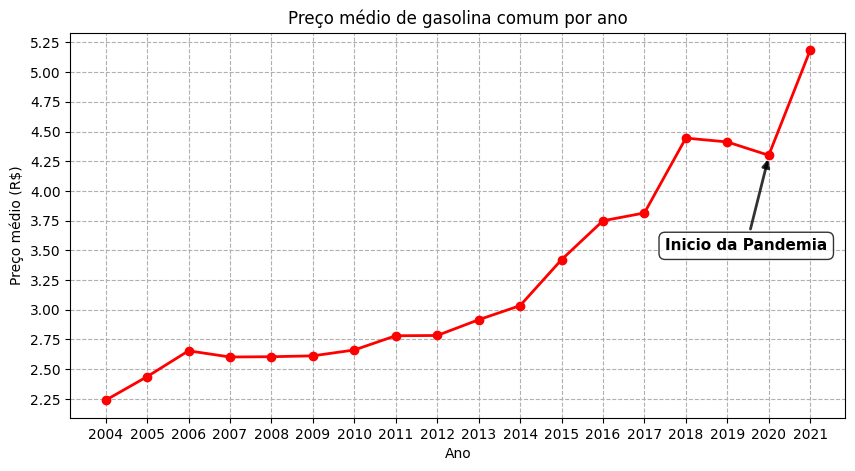

In [67]:
import matplotlib.pyplot as plt
#desenhando o grafico da gasolina comum
mpa.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    color='red',
    linewidth=2
)
plt.title('Preço médio de gasolina comum por ano')
plt.xlabel('Ano')
plt.ylabel('Preço médio (R$)')
plt.grid(True, linestyle='--')
plt.xticks(mpa.index) # o xticks dita a régua do eixo x
plt.yticks(np.arange(2.25,5.5,0.25)) #para criar uma escala específica, uso np.arrange(inicio,fim,passo) dentro de plt.ticks
#para escrever no gráfico
plt.annotate('Inicio da Pandemia',
    xy=(2020,4.29), #alvo da seta
    xytext=(2017.5,3.5), #onde o escrito vai ficar
    arrowprops=dict(facecolor='black',arrowstyle='-|>', lw=2, alpha=0.8),
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle='round, pad=0.4', facecolor='white', edgecolor='black', alpha=0.8)) # caixa em volta do escrito, pad=distancia do escrito até a borda;facecolor=cor do fundo, alpha=transparência
plt.show()

In [87]:
# Preço médio do etanol

df['PRODUTO'].unique()
eth=df[df['PRODUTO']=='ETANOL HIDRATADO']
mpaeh=eth.groupby('ANO')['PREÇO MÉDIO REVENDA'].mean()
print(mpaeh)

ANO
2004    1.528289
2005    1.700364
2006    1.967421
2007    1.751443
2008    1.771844
2009    1.772374
2010    1.936274
2011    2.203222
2012    2.225844
2013    2.313696
2014    2.444023
2015    2.620726
2016    3.124222
2017    3.177660
2018    3.425862
2019    3.458372
2020    3.460985
2021    4.121772
Name: PREÇO MÉDIO REVENDA, dtype: float64


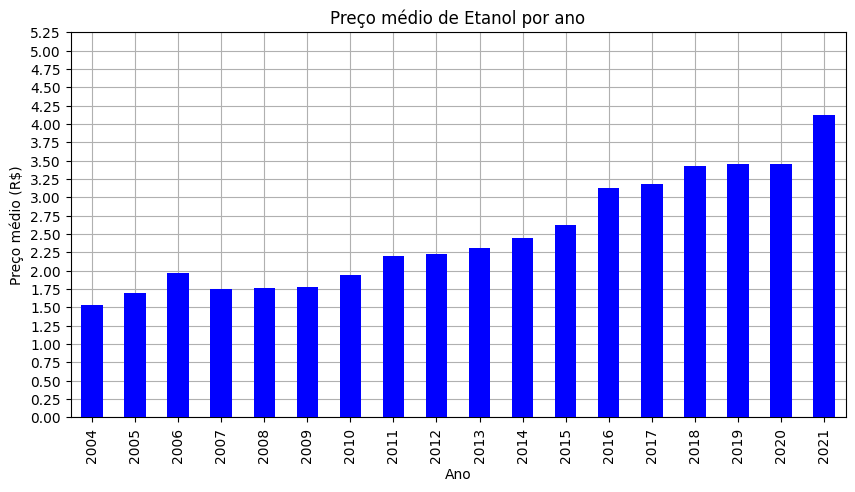

In [94]:
# gráfico do etanol
mpaeh.plot(
    kind='bar',
    figsize=(10,5),
    color='blue',
    zorder=3
)
plt.title('Preço médio de Etanol por ano')
plt.xlabel('Ano')
plt.ylabel('Preço médio (R$)')
plt.grid(True)
plt.yticks(np.arange(0,5.5,0.25))
plt.show()

In [98]:
# análise oleo diesel
df['PRODUTO'].unique()
od=df[df['PRODUTO']=='OLEO DIESEL']
mpod=od.groupby('ANO')['PREÇO MÉDIO REVENDA'].mean()
print(mpod)

ANO
2019    3.750111
2020    3.517985
2021    4.147167
Name: PREÇO MÉDIO REVENDA, dtype: float64


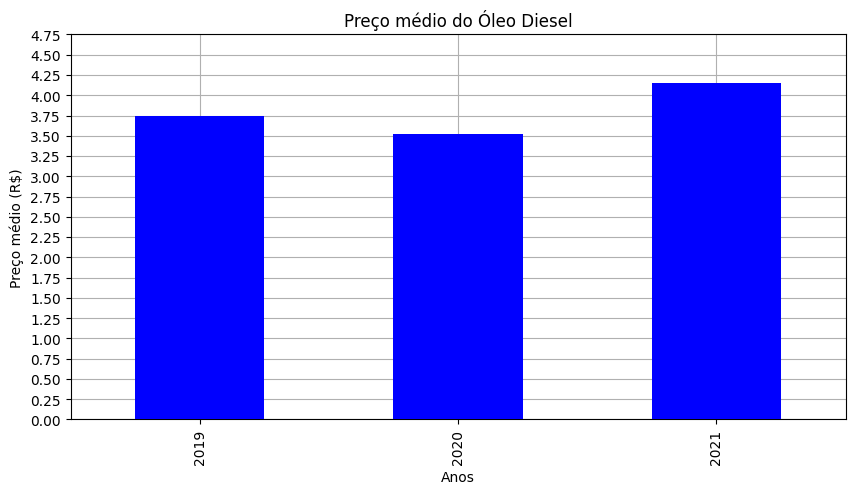

In [103]:
mpod.plot(
    kind='bar',
    figsize=(10,5),
    color='blue',
    zorder=3
)

plt.title('Preço médio do Óleo Diesel')
plt.xlabel('Anos')
plt.ylabel('Preço médio (R$)')
plt.yticks(np.arange(0,5,0.25))
plt.grid(True)
plt.show()